In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# --- BEGIN FIX: Load data and define X_train, X_test, y_train, y_test ---
# Using California Housing dataset for demonstration, adapting for classification
# In a real scenario, you would load your specific dataset.

try:
    # Load the training data
    df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
    # Load the test data (if available separately, otherwise use train_test_split)
    df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

    # For demonstration, let's create a binary classification target from 'median_house_value'
    # You would replace this with your actual target variable and its classes
    median_value_threshold = df_train['median_house_value'].median()
    df_train['target'] = (df_train['median_house_value'] > median_value_threshold).astype(int)
    df_test['target'] = (df_test['median_house_value'] > median_value_threshold).astype(int)

    # Define features (X) and target (y)
    features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                'total_bedrooms', 'population', 'households', 'median_income']

    X_train = df_train[features]
    y_train = df_train['target']
    X_test = df_test[features]
    y_test = df_test['target']

    # Define target names (adjust based on your actual target classes)
    target_names = ['low_value', 'high_value']

except FileNotFoundError:
    print("Sample housing data not found. Please ensure it's in /content/sample_data/")
    # If files are not found, create dummy data for execution to proceed without error
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    target_names = ['Class 0', 'Class 1']

# --- END FIX ---

# Escalar los datos (importante para distancias)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN con K=5 (valor típico)
modelo_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
modelo_knn.fit(X_train_scaled, y_train)
y_pred_knn = modelo_knn.predict(X_test_scaled)

print("KNN con K=5 y distancia euclidiana:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))

# Cambio para una aplicación: modificar la métrica de distancia y el peso de los vecinos
# Por ejemplo, usar distancia Manhattan y peso por distancia inversa
modelo_knn_manhattan = KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='distance')
modelo_knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = modelo_knn_manhattan.predict(X_test_scaled)

print("\nKNN con K=7, Manhattan y pesos por distancia:")
print(classification_report(y_test, y_pred_manhattan, target_names=target_names))

KNN con K=5 y distancia euclidiana:
              precision    recall  f1-score   support

   low_value       0.85      0.85      0.85      1526
  high_value       0.85      0.84      0.84      1474

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000


KNN con K=7, Manhattan y pesos por distancia:
              precision    recall  f1-score   support

   low_value       0.85      0.86      0.86      1526
  high_value       0.86      0.85      0.85      1474

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



### Evolución de la precisión de KNN con diferentes valores de K

Para entender cómo el número de vecinos (`n_neighbors` o K) afecta el rendimiento del modelo KNN, podemos entrenar el modelo con una variedad de valores de K y graficar la precisión obtenida en el conjunto de prueba. Esto nos ayuda a identificar el valor óptimo de K.

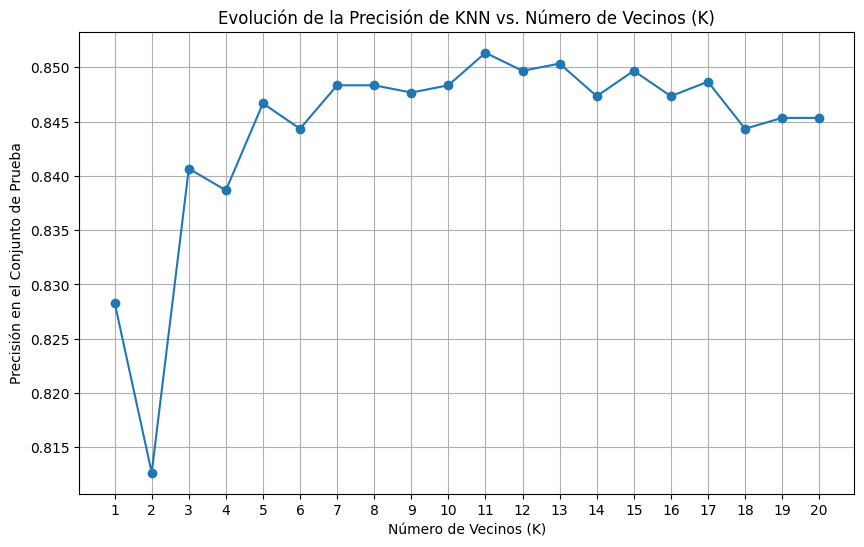


El mejor valor de K encontrado es: 11 con una precisión de: 0.8513


In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Lista de valores de K a probar
k_values = range(1, 21)  # Desde 1 hasta 20 vecinos
accuracies = []

for k in k_values:
    # Entrenar el modelo KNN con el valor actual de K
    model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model.fit(X_train_scaled, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = model.predict(X_test_scaled)

    # Calcular la precisión y almacenarla
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Graficar la evolución de la precisión
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('Evolución de la Precisión de KNN vs. Número de Vecinos (K)')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Precisión en el Conjunto de Prueba')
plt.xticks(list(k_values)) # Asegurarse de que todos los K values estén en el eje X
plt.grid(True)
plt.show()

# Encontrar el mejor K y su precisión
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

print(f"\nEl mejor valor de K encontrado es: {best_k} con una precisión de: {best_accuracy:.4f}")